## Key classification

Can we classify the key of a generation looking solely at its activations?

Smaller step: can we classify whether a piece is major or minor?

In [62]:
import numpy as np
from IPython.display import Audio
from scipy.io import wavfile
import os
from pathlib import Path
import librosa
import matplotlib.pyplot as plt

DATA_DIR = Path(os.path.abspath("./data"))

clip_id = "005"
audio_path = DATA_DIR / "audio" / f"{clip_id}.wav"

# Preview this audio
Audio(audio_path)

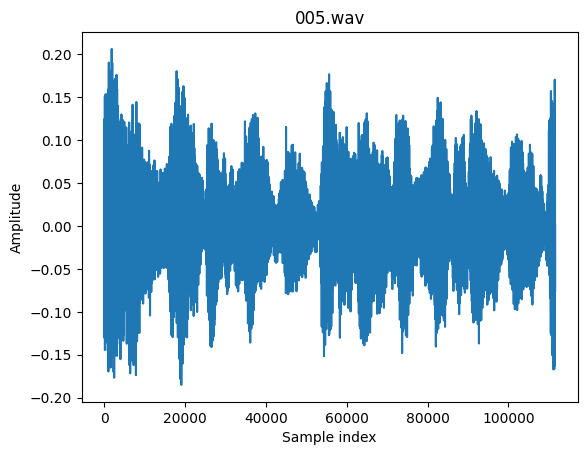

In [63]:
y, sr = librosa.load(audio_path)
plt.plot(y)
plt.xlabel("Sample index")
plt.ylabel("Amplitude")
plt.title(f"{clip_id}.wav")
plt.show()

chroma.shape=(12, 218)
0.8300429354636696 0.6931534588633559


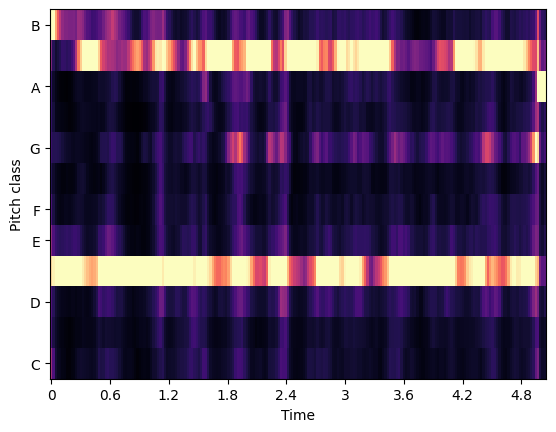

In [64]:
# Shows pitch over time
# By default, bins are 512 samples wide
chroma = librosa.feature.chroma_cqt(y=y, sr=sr)
print(f"{chroma.shape=}")

librosa.display.specshow(chroma, y_axis="chroma", x_axis="time")

# Krumhansl–Kessler profiles
kk_major = np.array([6.35, 2.23, 3.48, 2.33, 4.38, 4.09,
                     2.52, 5.19, 2.39, 3.66, 2.29, 2.88])
kk_minor = np.array([6.33, 2.68, 3.52, 5.38, 2.60, 3.53,
                     2.54, 4.75, 3.98, 2.69, 3.34, 3.17])

def best_match(chroma_vec, profile):
    # Produce major/minor profiles for each of the 12 notes
    scores = [np.corrcoef(chroma_vec, np.roll(profile, i))[0,1]
              for i in range(12)]
    return max(scores)

chroma_mean = chroma.mean(axis=1)
major_score = best_match(chroma_mean, kk_major)
minor_score = best_match(chroma_mean, kk_minor)

print(major_score, minor_score)